In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation, xi_generation, theta_generation
# from mis_dro.bayesian_conjugates import normal_gamma_posterior, normal_gamma_rvs
from mis_dro.dataset import data_generation_outliers
from mis_dro.newsvendor import newsvendor_cost
from mis_dro.models import ExponentialModel
from mis_dro.npl import Npl

In [31]:
generator = np.random.default_rng(seed=0)
num_observations = 10000

# data = data_generation(num_observations, random_state=generator)  # generate new observations
data = generator.normal(10, 10, num_observations)
# data = data_generation_outliers(params["num_observations"], contamination, random_state=generator)
# data = expon.rvs(scale=20.0, size=params["num_observations"], random_state=generator)

In [32]:
def normal_gamma_posterior(
        data: np.ndarray,
        mu_prior: float,
        kappa_prior: float,
        alpha_prior: float,
        beta_prior: float,
) -> tuple[float, float, float, float]:
    """Get the closed-form expression for normal-gamma posterior

    Returns:
        Posterior parameters for alpha, beta, mu, kappa

    Notes:
        See Section 3.3 of Murphy (2007).

    References:
        Murphy, K. P. (2007). Conjugate bayesian analysis of the gaussian distribution.
        Technical report, Department of Computer Science, The University of British Columbia.
    """
    num_observations = data.shape[0]
    data_mean = np.mean(data)
    mu_posterior = (kappa_prior * mu_prior + num_observations * data_mean) / (num_observations * kappa_prior)
    kappa_posterior = kappa_prior + num_observations
    alpha_posterior = alpha_prior + 0.5 * num_observations
    # beta_posterior = beta_prior + 0.5 * np.sum(np.square(data - data_mean)) + (0.5 * num_observations * kappa_prior * np.square(data_mean - mu_prior)) / (kappa_prior * num_observations)
    beta_posterior = beta_prior + 0.5 * np.mean(np.square(data - data_mean)) + (0.5 * num_observations * kappa_prior * np.square(data_mean - mu_prior)) / (kappa_prior * num_observations)
    return mu_posterior, kappa_posterior, alpha_posterior, beta_posterior

def normal_gamma_rvs(
        num_samples: int,
        mu: float,
        kappa: float,
        alpha: float,
        beta: float,
        generator = None
    ) -> np.ndarray:
    """Normal-gamma random variates"""
    samples = np.zeros((num_samples, 2))
    if not generator:
        generator = np.random.default_rng()
    precision_samples = generator.gamma(alpha, 1.0 / beta, num_samples)
    for i in range(num_samples):
        samples[i, 0] = generator.normal(mu, 1 / (kappa * precision_samples[i]), 1)
    samples[:, 1] = precision_samples
    return samples

In [33]:
num_posterior_samples = 100
p = 1  # numbers of unknown parameters

bayes_theta = theta_generation(data, num_posterior_samples, random_state=generator)

alpha_prior = 1
beta_prior = 1.0
mu_prior = 0.0
kappa_prior = 1.0
mu_posterior, kappa_posterior, alpha_posterior, beta_posterior = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
ng_theta = normal_gamma_rvs(num_posterior_samples, mu_posterior, kappa_posterior, alpha_posterior, beta_posterior, generator=generator)

# wll_model = ExponentialModel(num_observations)
# wll_npl = Npl(
#     data.reshape((num_observations, 1)),
#     num_posterior_samples,
#     p,
#     num_observations,
#     wll_model,
#     l=-1.0,
#     loss_fn="wll",
# )
# wll_npl.draw_samples(random_state=generator)
# wll_theta = wll_npl.sample

# mmd_model = ExponentialModel(num_observations)
# mmd_npl = Npl(
#     data.reshape((num_observations, 1)),
#     num_posterior_samples,
#     p,
#     num_observations,
#     mmd_model,
#     l=-1.0,
#     loss_fn="mmd",
# )
# mmd_npl.draw_samples(random_state=generator)
# mmd_theta = mmd_npl.sample

/tmp/dcs-tmp.u1508153/ipykernel_36340/705492431.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  samples[i, 0] = generator.normal(mu, 1 / (kappa * precision_samples[i]), 1)


In [34]:
num_likelihood_samples = 100
bayes_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
wll_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
mmd_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
ng_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
for i in range(num_posterior_samples):
    bayes_xi[i] = xi_generation(bayes_theta[i], num_likelihood_samples, random_state=generator)
    # wll_xi[i] = xi_generation(wll_theta[i], num_likelihood_samples, random_state=generator)
    # mmd_xi[i] = xi_generation(mmd_theta[i], num_likelihood_samples, random_state=generator)
    ng_xi[i] = generator.normal(ng_theta[i,0], ng_theta[i,1], size=num_likelihood_samples)

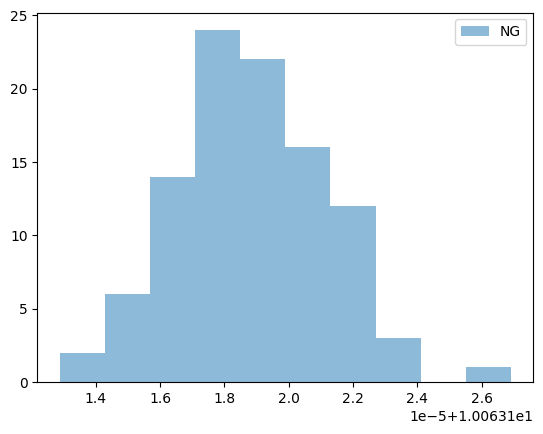

In [35]:
# plot the posterior
fig, ax = plt.subplots()
# ax.hist(bayes_theta, alpha=0.5, label="Bayes")
# ax.hist(wll_theta, alpha=0.5, label="WLL")
# ax.hist(mmd_theta, alpha=0.5, label="MMD")
# we plot only the mean of the normal-gamma 
# normal-gamma is tricky to visualise because its a 2D posterior over both mean and precision
ax.hist(ng_theta[:, 0], alpha=0.5, label="NG")

ax.legend()
fig.show()

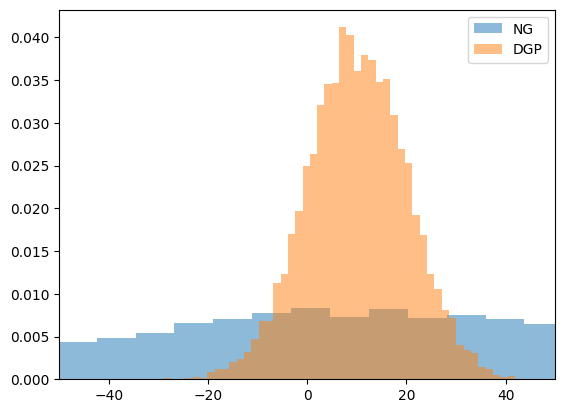

In [36]:
# plot the likelihood
fig, ax = plt.subplots()
nbins = 50
# ax.hist(bayes_xi.flatten(), alpha=0.5, label="Bayes", bins=nbins, density=True)
# ax.hist(wll_xi.flatten(), alpha=0.5, label="WLL", bins=nbins, density=True)
# ax.hist(mmd_xi.flatten(), alpha=0.5, label="MMD", bins=nbins, density=True)
ax.hist(ng_xi.flatten(), alpha=0.5, label="NG", bins=nbins, density=True)
ax.hist(data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax.legend()
ax.set_xlim(-50, 50)
plt.show()

In [9]:
ng_samples = normal_gamma_rvs(500, 0.0, 2.0, 1.0, 1.0)


/tmp/dcs-tmp.u1508153/ipykernel_36340/705492431.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  samples[i, 0] = generator.normal(mu, 1 / (kappa * precision_samples[i]), 1)


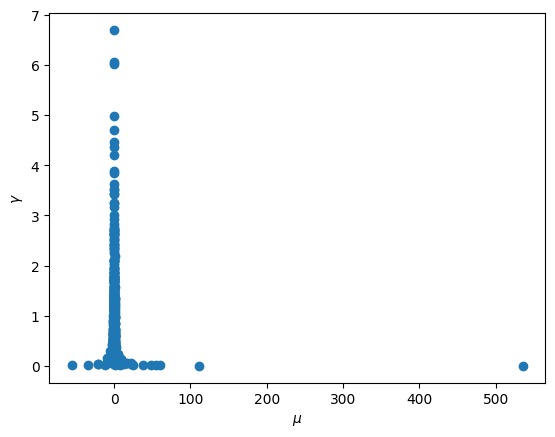

In [10]:
fig, ax = plt.subplots()
ax.scatter(ng_samples[:,0], ng_samples[:,1])
ax.set_xlabel("$\mu$")
ax.set_ylabel("$\gamma$")
fig.show()